# 🤪 Conditional WGAN-GP on CelebA Faces - Train

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DiveshJ8/Generative_Deep_Learning_2nd_Edition/blob/feature/assignment_week3/notebooks/04_gan/03_cgan/cgan_updated.ipynb)

In this notebook, we'll walk through the steps required to train your own Conditional GAN on the CelebA faces dataset.


In [1]:
# Setup for Google Colab and local environments
import os
import sys

# Python 3.12+ compatibility fix: 'imp' was removed in Python 3.12+, but legacy extensions may import it
if 'imp' not in sys.modules:
    try:
        import imp
    except ImportError:
        import importlib
        import types
        _imp = types.ModuleType('imp')
        _imp.reload = importlib.reload
        sys.modules['imp'] = _imp


# 1. If running in Google Colab, clone the repository branch and navigate into it
if "google.colab" in sys.modules:
    if os.path.exists("/content"):
        %cd /content
    if not os.path.exists("Generative_Deep_Learning_2nd_Edition"):
        !git clone -b feature/assignment_week3 https://github.com/DiveshJ8/Generative_Deep_Learning_2nd_Edition.git
    %cd /content/Generative_Deep_Learning_2nd_Edition
    if os.path.abspath(".") not in sys.path:
        sys.path.append(os.path.abspath("."))
    # Install required packages in Colab
    %pip install -q kaggle pandas kagglehub tensorboard

# 2. Add repository root to sys.path if running locally outside repository root
repo_root = None
for candidate in [
    os.path.abspath(os.path.join(os.getcwd(), "../../..")),
    os.path.abspath(os.getcwd()),
    os.path.abspath("/content/Generative_Deep_Learning_2nd_Edition"),
    "/app",
]:
    if os.path.exists(os.path.join(candidate, "notebooks")):
        repo_root = candidate
        break
if repo_root is None:
    repo_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if repo_root not in sys.path:
    sys.path.append(repo_root)

# 3. Ensure required packages are installed
try:
    import pandas
except ImportError:
    %pip install -q pandas

try:
    import tensorflow
except ImportError:
    %pip install -q tensorflow

try:
    import tensorboard
except ImportError:
    %pip install -q tensorboard


/content
Cloning into 'Generative_Deep_Learning_2nd_Edition'...
remote: Enumerating objects: 754, done.
remote: Counting objects: 100% (446/446), done.
remote: Compressing objects: 100% (215/215), done.
remote: Total 754 (delta 267), reused 281 (delta 227), pack-reused 308 (from 1)
Receiving objects: 100% (754/754), 39.68 MiB | 25.19 MiB/s, done.
Resolving deltas: 100% (417/417), done.
/content/Generative_Deep_Learning_2nd_Edition


The code has been adapted from the excellent [CGAN tutorial](https://keras.io/examples/generative/conditional_gan/) created by Sayak Paul, available on the Keras website.

In [2]:
# Python 3.12+ compatibility shim for 'imp' (used by legacy autoreload)
import sys
if 'imp' not in sys.modules:
    try:
        import imp
    except ImportError:
        import importlib
        import types
        _imp = types.ModuleType('imp')
        _imp.reload = importlib.reload
        sys.modules['imp'] = _imp

# Enable autoreload if available and supported
try:
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    optimizers,
)

# Import display and sample_batch utilities from notebooks.utils with standalone fallback
try:
    from notebooks.utils import display, sample_batch
except ModuleNotFoundError:
    def sample_batch(dataset):
        batch = dataset.take(1).get_single_element()
        if isinstance(batch, tuple):
            batch = batch[0]
        return batch.numpy()

    def display(
        images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
    ):
        """
        Displays n random images from each one of the supplied arrays.
        """
        if images.max() > 1.0:
            images = images / 255.0
        elif images.min() < 0.0:
            images = (images + 1.0) / 2.0

        plt.figure(figsize=size)
        for i in range(n):
            _ = plt.subplot(1, n, i + 1)
            plt.imshow(images[i].astype(as_type), cmap=cmap)
            plt.axis("off")

        if save_to:
            plt.savefig(save_to)
            print(f"\nSaved to {save_to}")

        plt.show()

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
tpus = tf.config.list_physical_devices('TPU')
print(f"GPU available: {bool(gpus)}")
if gpus:
    print(f"🚀 Using GPU: {gpus[0].name}")
elif tpus:
    print(f"⚡ TPU detected: {tpus[0].name}")
    print("ℹ️ Note: This CGAN / WGAN-GP implementation is optimized for GPU. For fastest training in Colab, switch to a T4 GPU runtime (Runtime -> Change runtime type -> T4 GPU).")
else:
    tpu_detected = False
    try:
        tf.distribute.cluster_resolver.TPUClusterResolver()
        tpu_detected = True
    except Exception:
        pass
    if tpu_detected:
        print("⚡ Connected to Colab TPU environment.")
        print("ℹ️ Note: This CGAN / WGAN-GP implementation is optimized for GPU. For fastest training in Colab, switch to a T4 GPU runtime (Runtime -> Change runtime type -> T4 GPU).")
    else:
        print("⚠️ No GPU detected (running on CPU). In Google Colab, go to: Runtime -> Change runtime type -> T4 GPU (Hardware Accelerator).")


TensorFlow version: 2.20.0
GPU available: True
🚀 Using GPU: /physical_device:GPU:0


## 0. Parameters <a name="parameters"></a>

In [3]:
IMAGE_SIZE = 64
CHANNELS = 3
CLASSES = 2
BATCH_SIZE = 128
Z_DIM = 128                     # Increased latent dimension from 32 to 128 for richer facial representation
LEARNING_RATE_C = 0.0002        # TTUR: Critic learning rate
LEARNING_RATE_G = 0.0001        # TTUR: Generator learning rate
ADAM_BETA_1 = 0.0               # Standard for WGAN-GP (removes momentum overshooting in zero-sum game)
ADAM_BETA_2 = 0.9               # Moving average of squared gradients
EPOCHS = 30                     # Target training epochs
# Bounded steps per epoch gives quick per-epoch feedback & saves preview images regularly.
# Set to an integer (e.g. 50 on CPU, 500 on GPU) or None to process the entire dataset (~1,582 batches) per epoch.
STEPS_PER_EPOCH = 50 if not tf.config.list_physical_devices('GPU') else 500
CRITIC_STEPS = 2                # 2 critic updates per generator step (efficient with TTUR)
GP_WEIGHT = 10.0                # 1-Lipschitz gradient penalty weight
DRIFT_WEIGHT = 0.001            # Prevents critic output from unbounded drift
EMA_DECAY = 0.999               # Exponential Moving Average decay for generator inference weights
LOAD_MODEL = False
LABEL = "Blond_Hair"  # Condition CGAN on the blond hair attribute


## 1. Prepare the data <a name="prepare"></a>

In [4]:
import os
import sys
import shutil
import zipfile
import getpass
import builtins

# Ensure builtins.exit is defined (fixes "name 'exit' is not defined" if Kaggle authentication fails)
if not hasattr(builtins, "exit"):
    builtins.exit = sys.exit
if not hasattr(builtins, "quit"):
    builtins.quit = sys.exit

# 1. Resolve dataset directory across Docker, local, Kaggle, Drive, or Colab environments
data_dir = None
candidate_dirs = [
    os.path.join(repo_root, "data", "celeba-dataset"),
    "/app/data/celeba-dataset",
    os.path.abspath("./data/celeba-dataset"),
    os.path.abspath("../../../data/celeba-dataset"),
    "/kaggle/input/celeba-dataset",
    "/content/data/celeba-dataset",
    "/content/Generative_Deep_Learning_2nd_Edition/data/celeba-dataset",
    "/content/drive/MyDrive/celeba-dataset",
    "/content/drive/MyDrive/data/celeba-dataset",
]

for candidate in candidate_dirs:
    if os.path.exists(os.path.join(candidate, "list_attr_celeba.csv")):
        data_dir = candidate
        break

# Check kagglehub cache directory if previously downloaded
if data_dir is None:
    kh_cache_base = os.path.expanduser("~/.cache/kagglehub/datasets/jessicali9530/celeba-dataset")
    if os.path.exists(kh_cache_base):
        for root, dirs, files in os.walk(kh_cache_base):
            if "list_attr_celeba.csv" in files:
                data_dir = root
                break

if data_dir is None:
    data_dir = os.path.join(repo_root, "data", "celeba-dataset")

attr_path = os.path.join(data_dir, "list_attr_celeba.csv")

# 2. If dataset is missing, automatically download and extract
if not os.path.exists(attr_path):
    print(f"Dataset not found at '{attr_path}'.")
    download_success = False

    # Strategy A: Use kagglehub (allows anonymous download of public datasets without API keys)
    try:
        print("Strategy A: Attempting download via kagglehub (no API key required)...\n")
        import kagglehub
        kh_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
        if kh_path and os.path.exists(kh_path):
            for root, dirs, files in os.walk(kh_path):
                if "list_attr_celeba.csv" in files:
                    data_dir = root
                    attr_path = os.path.join(data_dir, "list_attr_celeba.csv")
                    download_success = True
                    print(f"✅ Successfully downloaded dataset via kagglehub to: {data_dir}")
                    break
    except Exception as e_kh:
        print(f"kagglehub download attempt skipped/failed ({e_kh}). Proceeding to Kaggle API...")

    # Strategy B: Use Kaggle API / credentials
    if not download_success:
        print("Strategy B: Attempting download via Kaggle credentials...")

        # Check Google Colab Secrets (Left sidebar -> 🔑 Secrets -> KAGGLE_USERNAME, KAGGLE_KEY)
        if "google.colab" in sys.modules:
            try:
                from google.colab import userdata
                if "KAGGLE_USERNAME" not in os.environ and userdata.get("KAGGLE_USERNAME"):
                    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
                if "KAGGLE_KEY" not in os.environ and userdata.get("KAGGLE_KEY"):
                    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
            except Exception:
                pass

        # Check Google Drive for kaggle.json
        drive_kaggle_paths = [
            "/content/drive/MyDrive/kaggle.json",
            "/content/drive/MyDrive/.kaggle/kaggle.json",
            "/content/drive/MyDrive/Kaggle/kaggle.json",
        ]
        for p in drive_kaggle_paths:
            if os.path.exists(p):
                os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
                shutil.copy(p, os.path.expanduser("~/.kaggle/kaggle.json"))
                os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
                break

        # Check repository root for kaggle.json
        if os.path.exists(os.path.join(repo_root, "kaggle.json")):
            os.environ["KAGGLE_CONFIG_DIR"] = repo_root

        # Check if Kaggle credentials exist
        has_creds = (
            os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json"))
            or (os.environ.get("KAGGLE_CONFIG_DIR") and os.path.exists(os.path.join(os.environ["KAGGLE_CONFIG_DIR"], "kaggle.json")))
            or (os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"))
        )

        # Interactive fallback prompt if running in Colab without credentials
        if not has_creds and "google.colab" in sys.modules:
            print("\nKaggle credentials not detected.")
            print("To download the CelebA dataset from Kaggle, choose one:")
            print("  1. Enter your Kaggle Username & API Key")
            print("  2. Upload kaggle.json file")
            print("  3. Skip / cancel")
            try:
                choice = input("Enter choice (1/2/3, default=1): ").strip() or "1"
                if choice == "1":
                    uname = input("Kaggle Username: ").strip()
                    ukey = getpass.getpass("Kaggle API Key: ").strip()
                    if uname and ukey:
                        os.environ["KAGGLE_USERNAME"] = uname
                        os.environ["KAGGLE_KEY"] = ukey
                        has_creds = True
                elif choice == "2":
                    from google.colab import files
                    print("Please upload kaggle.json:")
                    uploaded = files.upload()
                    for fname in uploaded:
                        if fname.endswith(".json"):
                            os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
                            shutil.move(fname, os.path.expanduser("~/.kaggle/kaggle.json"))
                            os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
                            has_creds = True
                            break
            except Exception as e_input:
                print(f"Interactive prompt skipped: {e_input}")

        if has_creds:
            try:
                from kaggle.api.kaggle_api_extended import KaggleApi
                api = KaggleApi()
                api.authenticate()

                os.makedirs(data_dir, exist_ok=True)
                parent_dir = os.path.dirname(data_dir)
                zip_path = os.path.join(parent_dir, "celeba-dataset.zip")
                print("Downloading jessicali9530/celeba-dataset (~1.3 GB)...\n")
                api.dataset_download_files("jessicali9530/celeba-dataset", path=parent_dir, unzip=False)
                print("Extracting files...")
                with zipfile.ZipFile(zip_path, "r") as zip_ref:
                    zip_ref.extractall(data_dir)
                if os.path.exists(zip_path):
                    os.remove(zip_path)
                download_success = True
                print("✅ Download and extraction complete!")
            except Exception as e_api:
                print(f"Kaggle API download failed: {e_api}")

    # If still not found, raise clear actionable error
    if not os.path.exists(attr_path):
        raise FileNotFoundError(
            f"Could not find 'list_attr_celeba.csv' at '{attr_path}'.\n\n"
            f"To provide the CelebA dataset, please use one of these quick options:\n"
            f"1. In Google Colab, add your Kaggle credentials to Secrets (key icon 🔑 on left sidebar):\n"
            f"   - Name: KAGGLE_USERNAME, Value: <your_kaggle_username>\n"
            f"   - Name: KAGGLE_KEY, Value: <your_kaggle_api_key>\n"
            f"   (Generate key at: https://www.kaggle.com/settings -> 'Create New Token')\n\n"
            f"2. Or upload 'kaggle.json' to Colab / repository root.\n\n"
            f"3. Or run the shell downloader script:\n"
            f"   bash scripts/downloaders/download_kaggle_data.sh jessicali9530 celeba-dataset\n"
        )

# Load the label dataset
attributes = pd.read_csv(attr_path)
print(f"Loaded attributes from: {attr_path}")
print(attributes.columns)
attributes.head()


Dataset not found at '/content/Generative_Deep_Learning_2nd_Edition/data/celeba-dataset/list_attr_celeba.csv'.
Strategy A: Attempting download via kagglehub (no API key required)...

Using Colab cache for faster access to the 'celeba-dataset' dataset.
✅ Successfully downloaded dataset via kagglehub to: /kaggle/input/celeba-dataset
Loaded attributes from: /kaggle/input/celeba-dataset/list_attr_celeba.csv
Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'W

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [5]:
# Load the data
labels = attributes[LABEL].tolist()
int_labels = [1 if x == 1 else 0 for x in labels]

In [6]:
# Locate images directory (supports direct or nested folder structures)
images_dir = os.path.join(data_dir, "img_align_celeba")
nested_dir = os.path.join(images_dir, "img_align_celeba")
if os.path.exists(nested_dir) and any(f.endswith(".jpg") for f in os.listdir(nested_dir)[:5]):
    images_dir = nested_dir
elif not os.path.exists(images_dir) or not any(f.endswith(".jpg") for f in os.listdir(images_dir)[:5]):
    for root, dirs, files in os.walk(data_dir):
        if any(f.endswith(".jpg") for f in files[:5]):
            images_dir = root
            break

if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Images directory not found at '{images_dir}'")

# Native aspect-ratio preserving center crop directly during multi-threaded decode
train_data = utils.image_dataset_from_directory(
    images_dir,
    labels=int_labels,
    color_mode="rgb",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    crop_to_aspect_ratio=True,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)


Found 202599 files belonging to 2 classes.


In [7]:
# Preprocess and augment data with fused multi-threaded pipeline
def preprocess_and_augment(img, label):
    # Fast normalize to [-1, 1]
    img = (tf.cast(img, "float32") - 127.5) / 127.5
    # Random horizontal flip doubles effective facial dataset while preserving bilateral symmetry
    img = tf.image.random_flip_left_right(img)
    # One-hot encode attribute label
    one_hot_label = tf.one_hot(label, depth=CLASSES)
    return img, one_hot_label


# Note: image_dataset_from_directory already shuffles dataset with shuffle=True.
# Do NOT apply .shuffle(buffer_size=1024) on already-batched data, as that would
# buffer 1,024 batches (131,072 images / ~6.5 GB in RAM) before returning data.
train = (
    train_data.map(
        preprocess_and_augment,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


In [8]:
# Show some faces from the training set
train_sample = sample_batch(train)

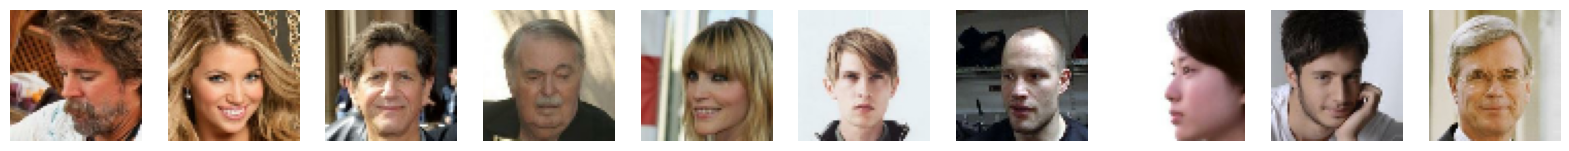

In [9]:
display(train_sample, cmap=None)

## 2. Build the GAN <a name="build"></a>

In [10]:
critic_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
label_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CLASSES))
x = layers.Concatenate(axis=-1)([critic_input, label_input])

# Progressive downsampling with Spectral Normalization (preserves 1-Lipschitz condition without dropout artifacts)
for filters in [64, 128, 256, 512]:
    x = layers.SpectralNormalization(
        layers.Conv2D(filters, kernel_size=4, strides=2, padding="same")
    )(x)
    x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2D(1, kernel_size=4, strides=1, padding="valid")(x)
critic_output = layers.Flatten()(x)

critic = models.Model([critic_input, label_input], critic_output, name="critic")
critic.summary()


Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 64, 64, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64, 5) │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 32, 32,    │      5,248 │ concatenate[0][0] │
│ (SpectralNormaliza… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 32,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 16, 16,    │    131,328 │ leaky_re_lu[0][0] │
│ (SpectralNormaliza… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 8, 8, 256) │    524,800 │ leaky_re_lu_1[0]… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 8, 8, 256) │          0 │ spectral_normali… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 4, 4, 512) │  2,098,176 │ leaky_re_lu_2[0]… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 4, 4, 512) │          0 │ spectral_normali… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 1)   │      8,193 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ conv2d_4[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,767,745 (10.56 MB)

 Trainable params: 2,766,785 (10.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
generator_input = layers.Input(shape=(Z_DIM,))
label_input = layers.Input(shape=(CLASSES,))
x = layers.Concatenate(axis=-1)([generator_input, label_input])
x = layers.Dense(4 * 4 * 512, use_bias=False)(x)
x = layers.Reshape((4, 4, 512))(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)

# 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64 using UpSampling2D + Conv2D to prevent checkerboard artifacts
for filters in [256, 128, 64]:
    x = layers.UpSampling2D(size=2, interpolation="nearest")(x)
    x = layers.Conv2D(filters, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)

x = layers.UpSampling2D(size=2, interpolation="nearest")(x)
generator_output = layers.Conv2D(
    CHANNELS, kernel_size=3, padding="same", activation="tanh", dtype="float32"
)(x)
generator = models.Model([generator_input, label_input], generator_output, name="generator")
generator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 130)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8192)      │  1,064,960 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 4, 512) │      2,048 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 4, 4, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 512) │          0 │ leaky_re_lu_4[0]… │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 256) │  1,179,648 │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 16,    │          0 │ leaky_re_lu_5[0]… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    294,912 │ up_sampling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 32, 32,    │          0 │ leaky_re_lu_6[0]… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     73,728 │ up_sampling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_7[0][0]  

 Total params: 2,618,819 (9.99 MB)

 Trainable params: 2,616,899 (9.98 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
class ConditionalWGAN(models.Model):
    def __init__(
        self,
        critic,
        generator,
        latent_dim,
        critic_steps=2,
        gp_weight=10.0,
        drift_weight=0.001,
        ema_decay=0.999,
    ):
        super(ConditionalWGAN, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.critic_steps = critic_steps
        self.gp_weight = gp_weight
        self.drift_weight = drift_weight
        self.ema_decay = ema_decay

        # Shadow EMA generator for high-fidelity inference
        self.generator_ema = models.clone_model(self.generator)
        self.generator_ema.set_weights(self.generator.get_weights())
        self.built = True

    def compile(self, c_optimizer, g_optimizer, run_eagerly=False):
        super(ConditionalWGAN, self).compile(run_eagerly=run_eagerly)
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.c_wass_loss_metric = metrics.Mean(name="c_wass_loss")
        self.c_gp_metric = metrics.Mean(name="c_gp")
        self.c_loss_metric = metrics.Mean(name="c_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [
            self.c_loss_metric,
            self.c_wass_loss_metric,
            self.c_gp_metric,
            self.g_loss_metric,
        ]

    def gradient_penalty(
        self, batch_size, real_images, fake_images, image_one_hot_labels
    ):
        # Sample uniformly along the straight line between real and generated images
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.critic(
                [interpolated, image_one_hot_labels], training=True
            )

        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]) + 1e-12)
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, data):
        real_images, one_hot_labels = data

        batch_size = tf.shape(real_images)[0]
        image_height = tf.shape(real_images)[1]
        image_width = tf.shape(real_images)[2]

        # Vectorized single-op tile to match critic spatial input format (B, H, W, CLASSES)
        image_one_hot_labels = tf.tile(
            one_hot_labels[:, None, None, :], [1, image_height, image_width, 1]
        )

        for _ in range(self.critic_steps):
            random_latent_vectors = tf.random.normal(
                shape=(batch_size, self.latent_dim)
            )

            with tf.GradientTape() as tape:
                fake_images = self.generator(
                    [random_latent_vectors, one_hot_labels], training=True
                )
                fake_predictions = self.critic(
                    [fake_images, image_one_hot_labels], training=True
                )
                real_predictions = self.critic(
                    [real_images, image_one_hot_labels], training=True
                )

                c_wass_loss = tf.reduce_mean(fake_predictions) - tf.reduce_mean(
                    real_predictions
                )
                c_gp = self.gradient_penalty(
                    batch_size, real_images, fake_images, image_one_hot_labels
                )
                c_drift = self.drift_weight * tf.reduce_mean(
                    tf.square(real_predictions)
                )
                c_loss = c_wass_loss + c_gp * self.gp_weight + c_drift

            c_gradient = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(
                zip(c_gradient, self.critic.trainable_variables)
            )

        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )

        with tf.GradientTape() as tape:
            fake_images = self.generator(
                [random_latent_vectors, one_hot_labels], training=True
            )
            fake_predictions = self.critic(
                [fake_images, image_one_hot_labels], training=True
            )
            g_loss = -tf.reduce_mean(fake_predictions)

        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )

        # Update shadow EMA generator weights for smooth, artifact-free inference
        for ema_w, g_w in zip(self.generator_ema.weights, self.generator.weights):
            ema_w.assign_sub((1.0 - self.ema_decay) * (ema_w - g_w))

        self.c_loss_metric.update_state(c_loss)
        self.c_wass_loss_metric.update_state(c_wass_loss)
        self.c_gp_metric.update_state(c_gp)
        self.g_loss_metric.update_state(g_loss)

        return {m.name: m.result() for m in self.metrics}


In [13]:
# Create a GAN with drift penalty and EMA weight tracking
cgan = ConditionalWGAN(
    critic=critic,
    generator=generator,
    latent_dim=Z_DIM,
    critic_steps=CRITIC_STEPS,
    gp_weight=GP_WEIGHT,
    drift_weight=DRIFT_WEIGHT,
    ema_decay=EMA_DECAY,
)


In [14]:
if LOAD_MODEL:
    if os.path.exists("./checkpoint_updated/checkpoint.weights.h5"):
        cgan.load_weights("./checkpoint_updated/checkpoint.weights.h5")
    elif os.path.exists("./checkpoint/checkpoint.weights.h5"):
        cgan.load_weights("./checkpoint/checkpoint.weights.h5")
    elif os.path.exists("./checkpoint/checkpoint.ckpt"):
        cgan.load_weights("./checkpoint/checkpoint.ckpt")

## 3. Train the GAN <a name="train"></a>

In [15]:
# Enable mixed precision for Tensor Core acceleration on NVIDIA GPU if available
if bool(tf.config.list_physical_devices('GPU')):
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('🚀 Mixed precision (mixed_float16) enabled for GPU acceleration.')
    except Exception as e:
        print(f'Notice: Mixed precision not enabled ({e}).')

# Compile the GAN with Two Time-Scale Update Rule (TTUR) and beta_1=0.0
cgan.compile(
    c_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE_C, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
    g_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE_G, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
    run_eagerly=False,
)


🚀 Mixed precision (mixed_float16) enabled for GPU acceleration.


In [16]:
# Create directories for checkpoints, logs, and output images
import os
os.makedirs("./checkpoint_updated", exist_ok=True)
os.makedirs("./output_updated", exist_ok=True)
os.makedirs("./logs_updated", exist_ok=True)

# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint_updated/checkpoint.weights.h5",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = None
try:
    import tensorboard  # noqa: F401
    tensorboard_callback = callbacks.TensorBoard(log_dir="./logs_updated")
except Exception as e:
    print(f"Notice: TensorBoard logging skipped ({e}).")


class GANImprovementEarlyStopping(callbacks.Callback):
    """
    Monitors GAN training progress and guards against numerical divergence (NaN/Inf),
    without erroneously terminating when Wasserstein distance grows negative.
    """

    def __init__(
        self,
        monitor="c_loss",
        min_epochs=10,
        patience=20,
        min_delta=0.01,
        ema_alpha=0.1,
        gp_divergence_threshold=100.0,
        restore_best_weights=True,
        verbose=1,
    ):
        super(GANImprovementEarlyStopping, self).__init__()
        self.monitor = monitor
        self.min_epochs = min_epochs
        self.patience = patience
        self.min_delta = min_delta
        self.ema_alpha = ema_alpha
        self.gp_divergence_threshold = gp_divergence_threshold
        self.restore_best_weights = restore_best_weights
        self.verbose = verbose

        self.best_score = np.inf
        self.best_epoch = 0
        self.best_weights = None
        self.wait = 0
        self.smoothed_loss = None

    def on_train_begin(self, logs=None):
        self.best_score = np.inf
        self.best_epoch = 0
        self.best_weights = None
        self.wait = 0
        self.smoothed_loss = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_loss = logs.get(self.monitor)
        gp_val = logs.get("c_gp", 0.0)

        if current_loss is None:
            return

        # Check for NaN, Inf, or exploding gradient penalty (> 100)
        # Note: c_loss naturally becomes negative in WGAN-GP; abs(c_loss) is NOT a divergence condition!
        if (
            np.isnan(current_loss)
            or np.isinf(current_loss)
            or np.isnan(gp_val)
            or gp_val > self.gp_divergence_threshold
        ):
            if self.verbose > 0:
                print(
                    f"\n[EarlyStopping] Epoch {epoch}: Divergence or NaN detected "
                    f"({self.monitor}={current_loss}, c_gp={gp_val}). Terminating training!"
                )
            self.model.stop_training = True
            if self.restore_best_weights and self.best_weights is not None:
                if self.verbose > 0:
                    print(
                        f"[EarlyStopping] Restoring best model weights from epoch {self.best_epoch}."
                    )
                self.model.set_weights(self.best_weights)
            return

        # Update Exponential Moving Average of critic loss
        if self.smoothed_loss is None:
            self.smoothed_loss = current_loss
        else:
            self.smoothed_loss = (
                self.ema_alpha * current_loss
                + (1.0 - self.ema_alpha) * self.smoothed_loss
            )


class ImageGenerator(callbacks.Callback):
    """
    Generates images at epoch intervals using FIXED latent seeds and the shadow EMA generator.
    Tracking the exact same seeds across epochs allows direct visual inspection of quality improvement.
    """
    def __init__(self, num_img, latent_dim, save_freq=1):
        super(ImageGenerator, self).__init__()
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.save_freq = save_freq

        # Fixed seeds for deterministic progression monitoring
        self.fixed_z = tf.random.truncated_normal(
            shape=(self.num_img, self.latent_dim), mean=0.0, stddev=0.8, seed=42
        )
        self.zero_label = tf.repeat(tf.constant([[1.0, 0.0]]), repeats=self.num_img, axis=0)
        self.one_label = tf.repeat(tf.constant([[0.0, 1.0]]), repeats=self.num_img, axis=0)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch % self.save_freq != 0) and (epoch != 0):
            return

        # Use EMA generator if available for smoother inference
        gen_model = getattr(self.model, "generator_ema", self.model.generator)

        # 0 label (non-blond)
        gen_imgs_0 = gen_model([self.fixed_z, self.zero_label])
        gen_imgs_0 = (gen_imgs_0 * 127.5 + 127.5).numpy()
        display(
            gen_imgs_0,
            save_to=f"./output_updated/generated_img_updated_{epoch:03d}_label_0.png",
            cmap=None,
        )
        plt.close()

        # 1 label (blond)
        gen_imgs_1 = gen_model([self.fixed_z, self.one_label])
        gen_imgs_1 = (gen_imgs_1 * 127.5 + 127.5).numpy()
        display(
            gen_imgs_1,
            save_to=f"./output_updated/generated_img_updated_{epoch:03d}_label_1.png",
            cmap=None,
        )
        plt.close('all')


Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - c_gp: 0.0850 - c_loss: -12.2037 - c_wass_loss: -13.5648 - g_loss: 14.9772
Saved to ./output_updated/generated_img_updated_000_label_0.png


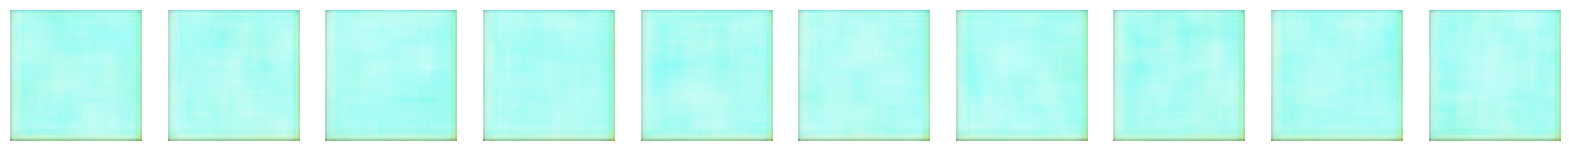


Saved to ./output_updated/generated_img_updated_000_label_1.png


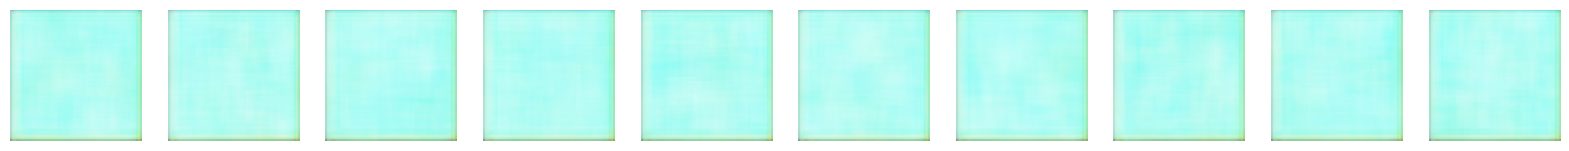

500/500 ━━━━━━━━━━━━━━━━━━━━ 239s 396ms/step - c_gp: 0.0438 - c_loss: -7.6278 - c_wass_loss: -8.5611 - g_loss: 9.2825 
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - c_gp: 0.0308 - c_loss: -5.9971 - c_wass_loss: -6.6613 - g_loss: 10.9567
Saved to ./output_updated/generated_img_updated_001_label_0.png


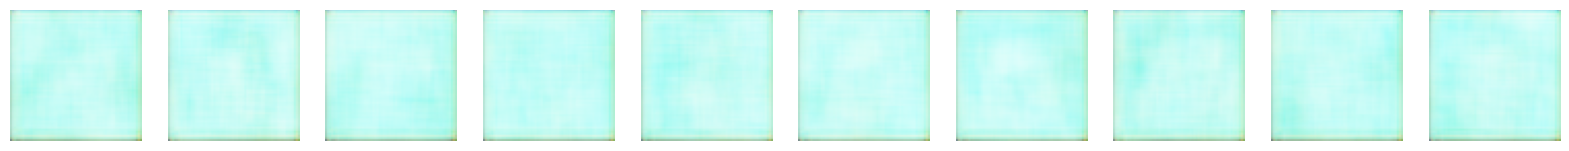


Saved to ./output_updated/generated_img_updated_001_label_1.png


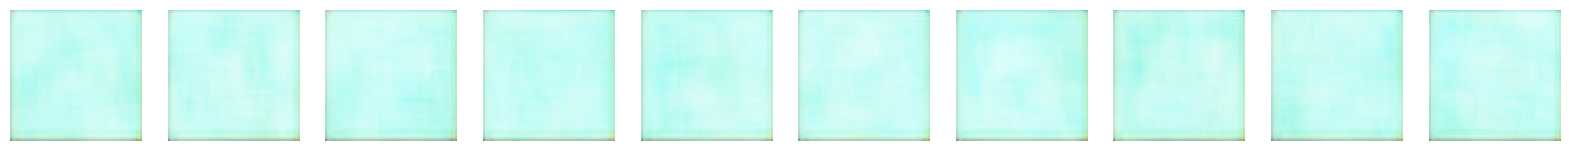

500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 410ms/step - c_gp: 0.0321 - c_loss: -5.8835 - c_wass_loss: -6.5262 - g_loss: 6.4967
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - c_gp: 0.0339 - c_loss: -5.2898 - c_wass_loss: -5.8906 - g_loss: 0.5104
Saved to ./output_updated/generated_img_updated_002_label_0.png


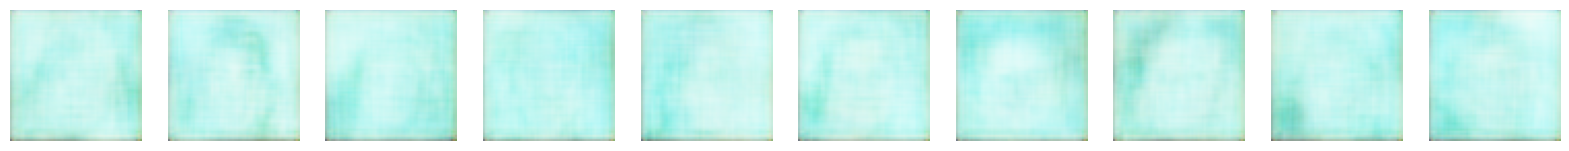


Saved to ./output_updated/generated_img_updated_002_label_1.png


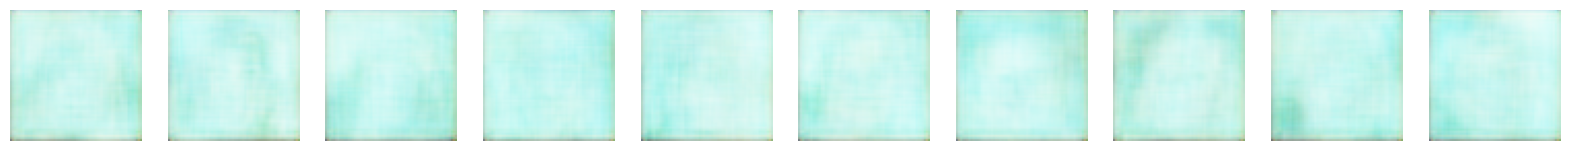

500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 411ms/step - c_gp: 0.0341 - c_loss: -5.2738 - c_wass_loss: -5.8580 - g_loss: 4.0339
Epoch 4/30
 83/500 ━━━━━━━━━━━━━━━━━━━━ 5:02 725ms/step - c_gp: 0.0325 - c_loss: -5.2469 - c_wass_loss: -5.8210 - g_loss: -2.2224

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Saved to ./output_updated/generated_img_updated_003_label_0.png


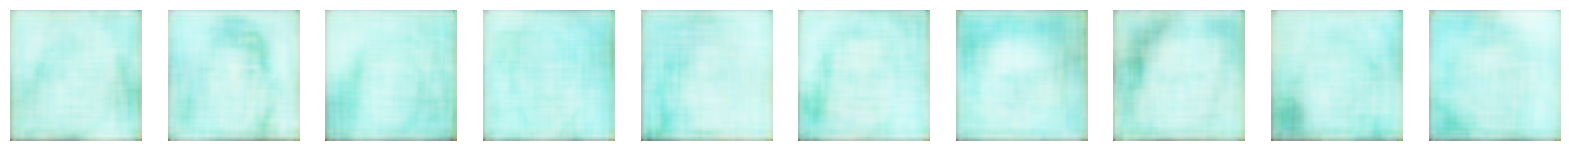


Saved to ./output_updated/generated_img_updated_003_label_1.png


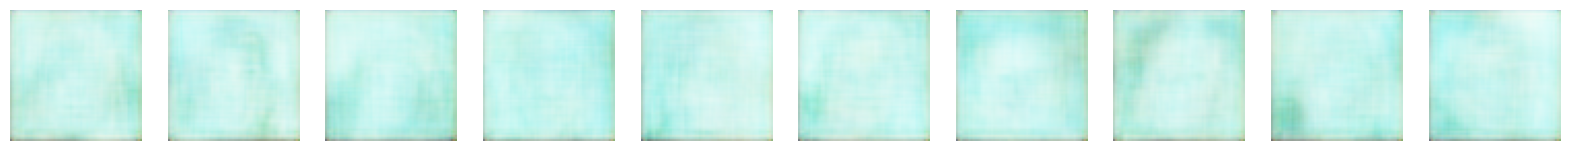

500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - c_gp: 0.0338 - c_loss: -5.2750 - c_wass_loss: -5.8549 - g_loss: 0.7790  
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - c_gp: 0.0402 - c_loss: -5.1948 - c_wass_loss: -5.8186 - g_loss: -0.8495
Saved to ./output_updated/generated_img_updated_004_label_0.png


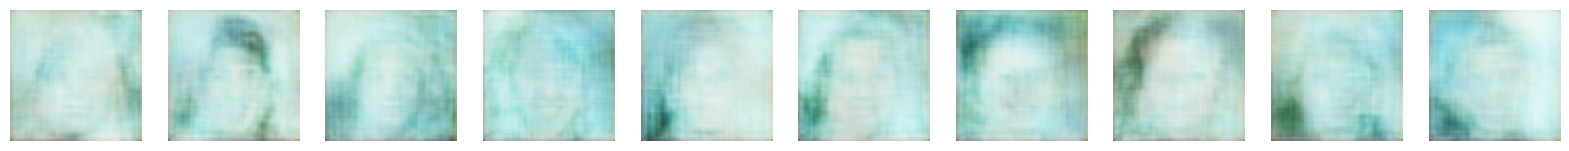


Saved to ./output_updated/generated_img_updated_004_label_1.png


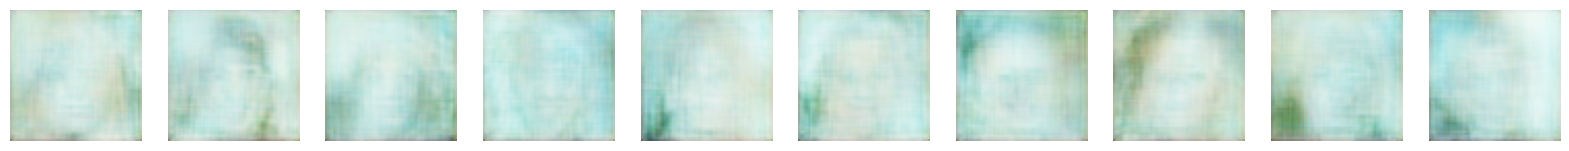

500/500 ━━━━━━━━━━━━━━━━━━━━ 207s 414ms/step - c_gp: 0.0391 - c_loss: -5.1721 - c_wass_loss: -5.7797 - g_loss: -0.4371
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - c_gp: 0.0438 - c_loss: -5.2207 - c_wass_loss: -5.8227 - g_loss: 1.6661
Saved to ./output_updated/generated_img_updated_005_label_0.png


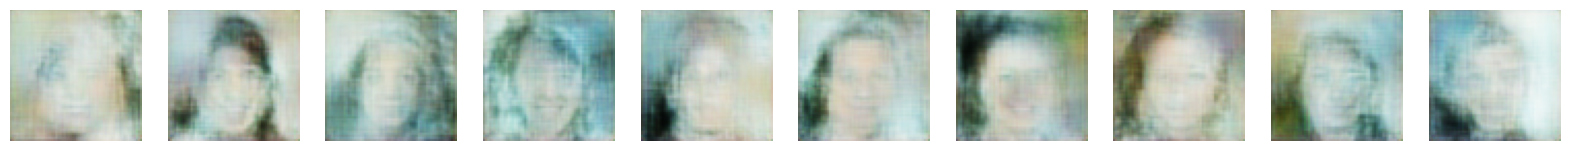


Saved to ./output_updated/generated_img_updated_005_label_1.png


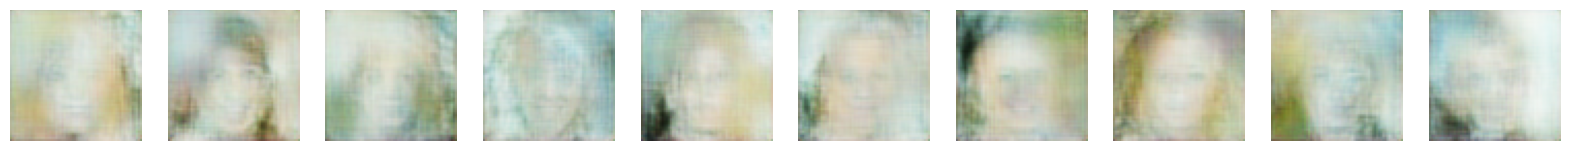

500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 410ms/step - c_gp: 0.0430 - c_loss: -5.2587 - c_wass_loss: -5.8506 - g_loss: 1.6228
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - c_gp: 0.0423 - c_loss: -5.1632 - c_wass_loss: -5.7116 - g_loss: 1.8316
Saved to ./output_updated/generated_img_updated_006_label_0.png


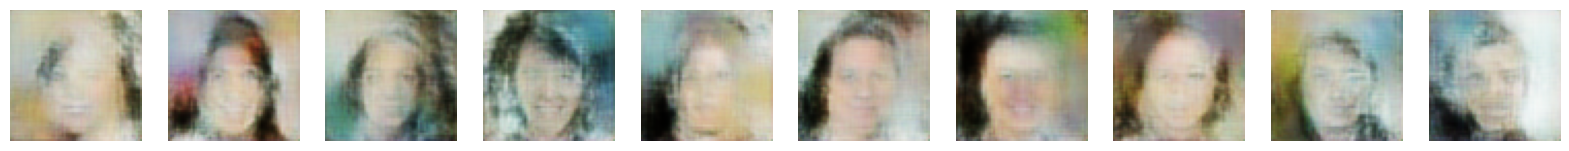


Saved to ./output_updated/generated_img_updated_006_label_1.png


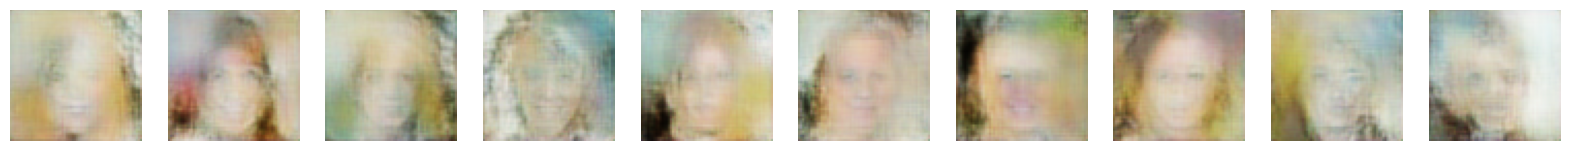

500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 411ms/step - c_gp: 0.0406 - c_loss: -5.1600 - c_wass_loss: -5.6919 - g_loss: 1.3095
Epoch 8/30
 83/500 ━━━━━━━━━━━━━━━━━━━━ 2:49 407ms/step - c_gp: 0.0376 - c_loss: -5.1582 - c_wass_loss: -5.6266 - g_loss: 3.1760
Saved to ./output_updated/generated_img_updated_007_label_0.png


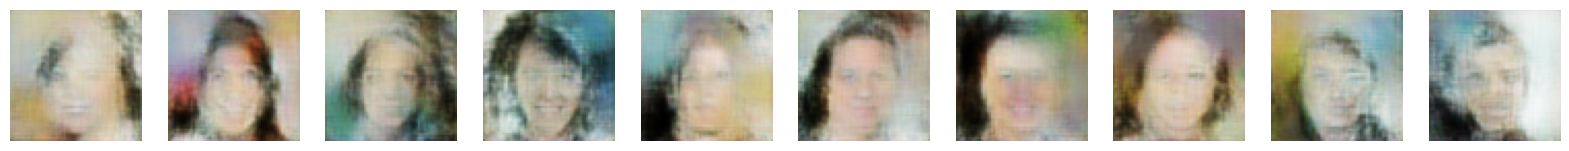


Saved to ./output_updated/generated_img_updated_007_label_1.png


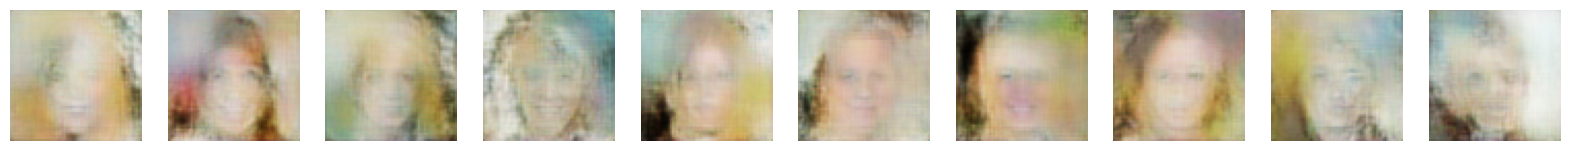

500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - c_gp: 0.0355 - c_loss: -5.2085 - c_wass_loss: -5.6618 - g_loss: 1.0617  
Epoch 9/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - c_gp: 0.0374 - c_loss: -5.0778 - c_wass_loss: -5.5590 - g_loss: 0.1627
Saved to ./output_updated/generated_img_updated_008_label_0.png


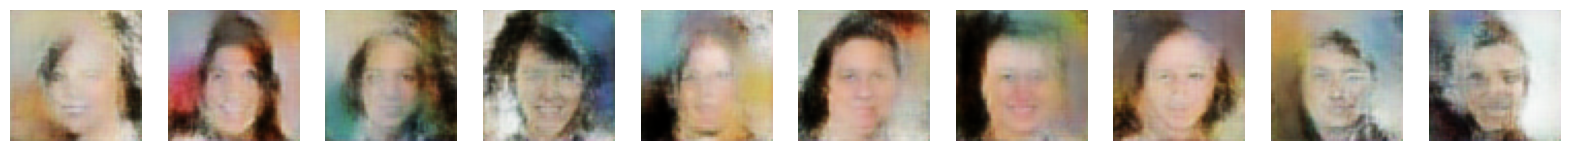


Saved to ./output_updated/generated_img_updated_008_label_1.png


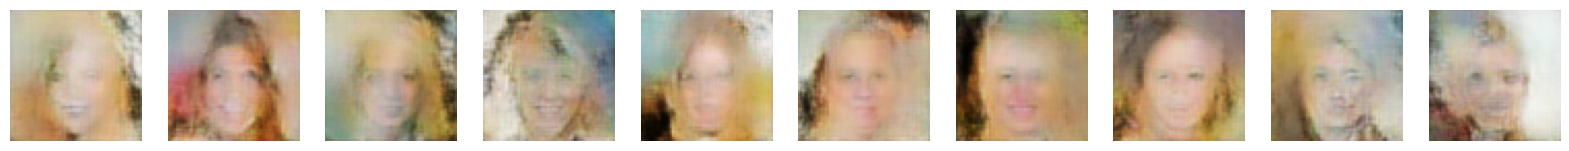

500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 411ms/step - c_gp: 0.0347 - c_loss: -4.9549 - c_wass_loss: -5.4066 - g_loss: 0.7583
Epoch 10/30
239/500 ━━━━━━━━━━━━━━━━━━━━ 1:46 409ms/step - c_gp: 0.0303 - c_loss: -4.8669 - c_wass_loss: -5.2689 - g_loss: 0.4784

KeyboardInterrupt: 

In [17]:
early_stopping_callback = GANImprovementEarlyStopping(
    monitor="c_loss",
    min_epochs=10,
    patience=20,
    min_delta=0.01,
    restore_best_weights=True,
    verbose=1,
)

callbacks_list = [
    model_checkpoint_callback,
    early_stopping_callback,
    ImageGenerator(num_img=10, latent_dim=Z_DIM, save_freq=1),
]
if tensorboard_callback is not None:
    callbacks_list.insert(1, tensorboard_callback)

history = cgan.fit(
    train,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks_list,
)


In [18]:
# Save the final models
import os
os.makedirs("./models_updated", exist_ok=True)
generator.save("./models_updated/generator_updated.keras")
critic.save("./models_updated/critic_updated.keras")

## Generate images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


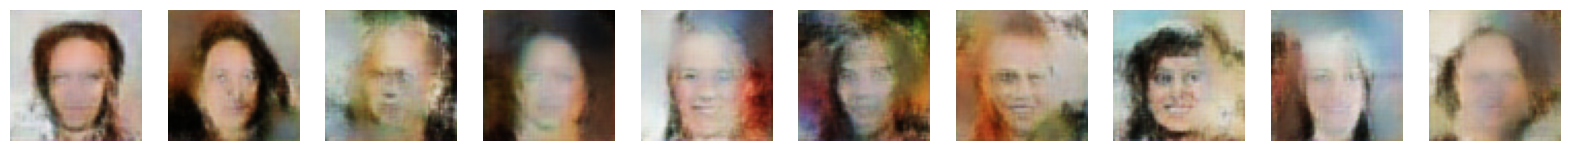

In [19]:
# 0 label (non-blond) using EMA generator and Latent Truncation Trick (psi=0.8)
# Truncation trick prevents extreme Gaussian tails that cause facial distortion
z_sample = tf.random.truncated_normal(shape=(10, Z_DIM), mean=0.0, stddev=0.8, seed=42).numpy()
class_label_0 = np.repeat([[1, 0]], 10, axis=0)

# Use EMA generator if trained, fallback to raw generator
eval_generator = getattr(cgan, "generator_ema", cgan.generator)
imgs_0 = eval_generator.predict([z_sample, class_label_0])
display(imgs_0, cmap=None)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


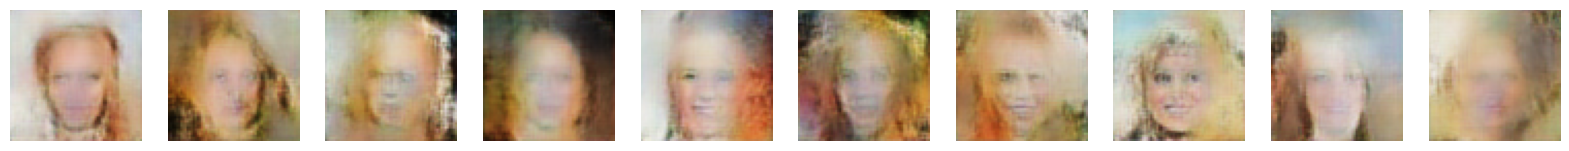

In [20]:
# 1 label (blond) - using the same z_sample with EMA generator for direct attribute comparison
class_label_1 = np.repeat([[0, 1]], 10, axis=0)
imgs_1 = eval_generator.predict([z_sample, class_label_1])
display(imgs_1, cmap=None)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
Continuous attribute interpolation (Non-blond -> Blond):


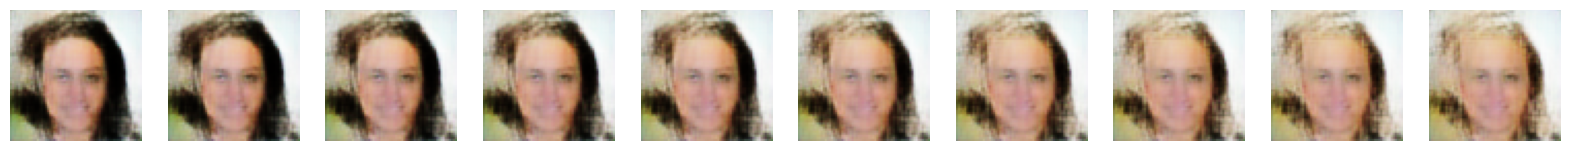

In [21]:
# Smooth conditional interpolation: transition a single face from non-blond to blond
alpha_steps = np.linspace(0.0, 1.0, 10)[:, None]
interpolated_labels = np.hstack([1.0 - alpha_steps, alpha_steps])  # Shape: (10, 2)
single_z = tf.repeat(tf.random.truncated_normal(shape=(1, Z_DIM), mean=0.0, stddev=0.8, seed=123), repeats=10, axis=0).numpy()

interp_imgs = eval_generator.predict([single_z, interpolated_labels])
print("Continuous attribute interpolation (Non-blond -> Blond):")
display(interp_imgs, cmap=None)
